# Day 23: Understanding and Implementing Logistic Regression

---

## Objectives:

- Comprehend the fundamentals of **Logistic Regression**.
- Implement Logistic Regression to predict binary outcomes.
- Interpret model outputs, including probabilities.
- Apply the model to a real-world dataset.
- Utilize enriched visualizations to enhance understanding.

---

## 1. Introduction to Logistic Regression

### 1.1 What is Logistic Regression?

Logistic Regression is a statistical method used for binary classification problems, where the outcome variable is categorical with two possible outcomes (e.g., yes/no, true/false, success/failure). Unlike linear regression, which predicts continuous values, logistic regression predicts the probability of a categorical outcome.

### 1.2 The Sigmoid Function

At the core of logistic regression lies the **sigmoid function**, defined as:

\[ \sigma(z) = \frac{1}{1 + e^{-z}} \]

This function maps any real-valued number into the (0, 1) interval, making it suitable for probability estimation.

### 1.3 Decision Boundary

The decision boundary is the threshold at which we decide the class label based on the predicted probability. Typically, a threshold of 0.5 is used:

- If \( P(y=1|X) \geq 0.5 \), predict class 1.
- If \( P(y=1|X) < 0.5 \), predict class 0.

---

## 2. Dataset Overview

We'll utilize the **Breast Cancer Wisconsin (Diagnostic) Dataset**, which is commonly used for binary classification tasks.

**Features:**

- **Mean Radius**: Mean of distances from center to points on the perimeter.
- **Mean Texture**: Standard deviation of gray-scale values.
- **Mean Perimeter**: Mean size of the core tumor.
- **Mean Area**: Mean area of the tumor.
- **Mean Smoothness**: Mean of local variation in radius lengths.
- *(and more features related to tumor characteristics)*

**Target Variable:**

- **Diagnosis**: Indicates whether the tumor is benign (0) or malignant (1).

---

## 3. Data Loading and Exploration

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.datasets import load_breast_cancer

In [3]:
#Load Dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [4]:
#Display the first few rows of the dataset
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# 4. Exploratory Data Analysis

In [5]:
#Statistical Summary
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [6]:
#Check the missing values
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

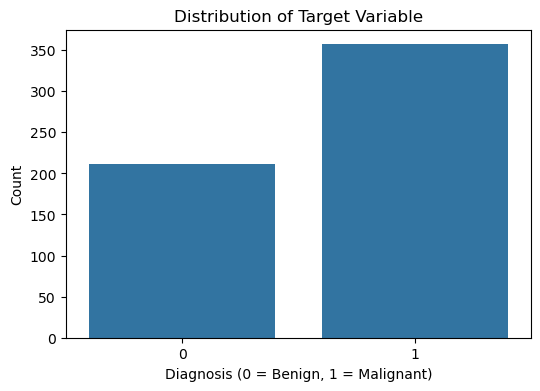

In [8]:
#Distribution of the target variable
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable')
plt.xlabel('Diagnosis (0 = Benign, 1 = Malignant)')
plt.ylabel('Count')
plt.show()

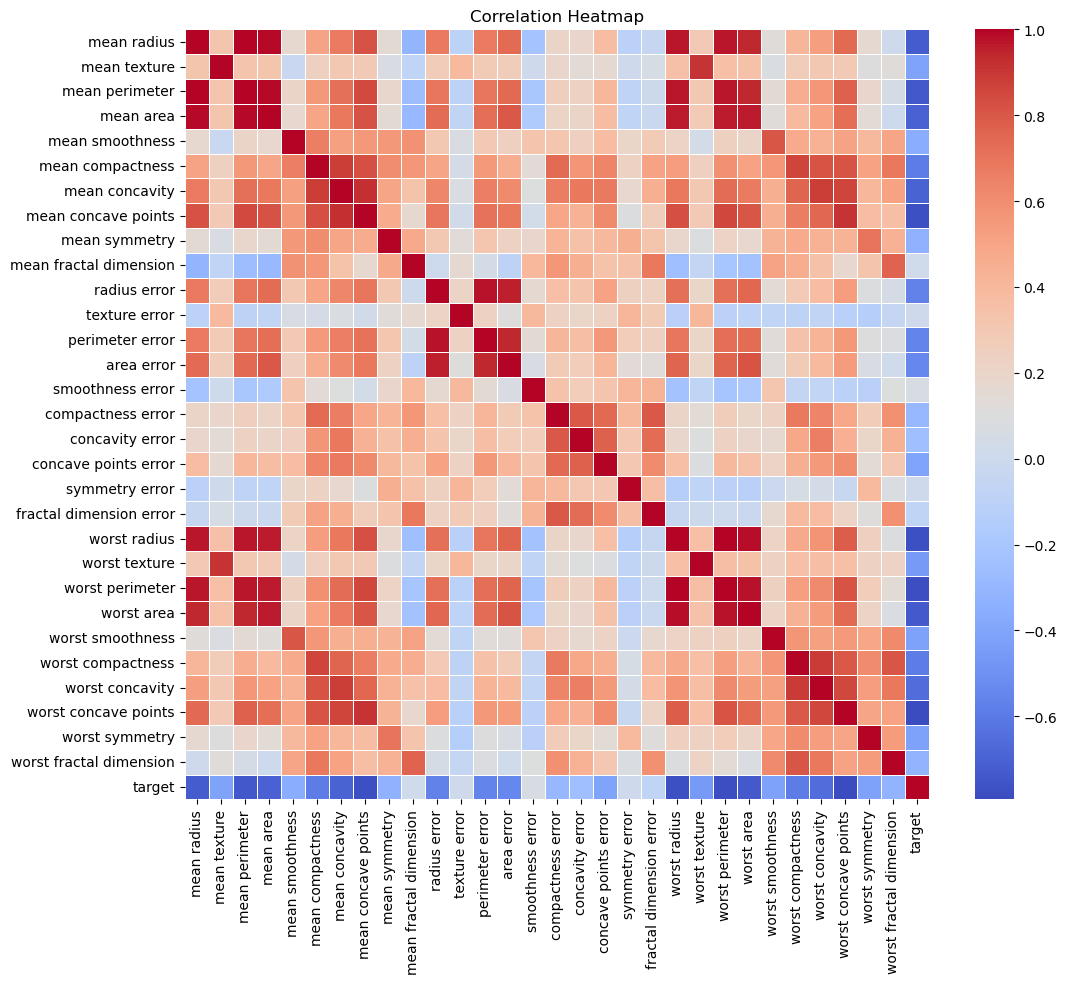

In [9]:
#Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidth=0.5)
plt.title('Correlation Heatmap')
plt.show()

# 5. Data Preprocessing

In [10]:
# Define feature variables (X) and target variable (y)
X = df.drop('target', axis=1)
y = df['target']

In [11]:
#Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

# 6. Model Training

In [12]:
#Initialize and train the Logistic Regression Model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

# 7. Model Evaluation

In [13]:
#Predict on the test set
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [15]:
#Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



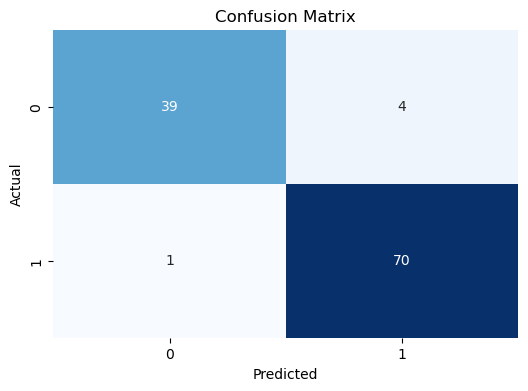

In [16]:
#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

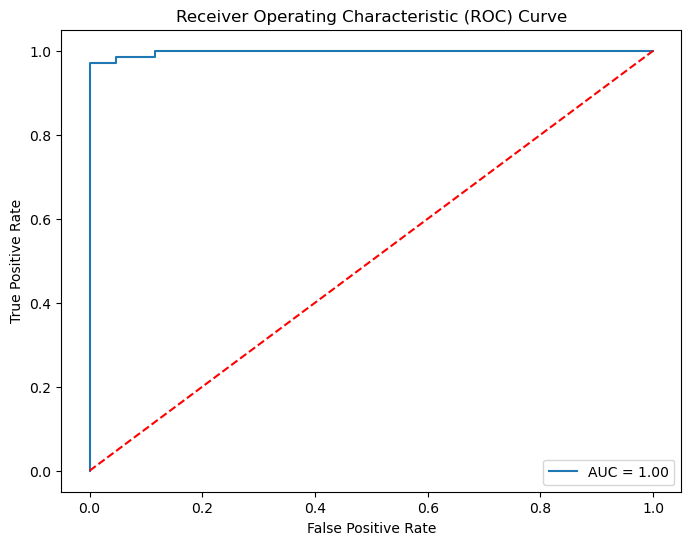

In [18]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_prob):.2f}')
plt.plot([0,1],[0,1], linestyle='--', color='r')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# 8. Interpretation of Results
- **Classification Report**: Provides precision, recall, f1-score, and support for each class.
- **Confusion Matrix**: Displays the true positives, true negatives, false positives, and false negatives.
- **ROC Curve**: Illustrates the diagnostic ability of the classifier; the AUC (Area Under the Curve) indicates the model's ability to distinguish between classes.

# 9. Conclusion
In this notebook, we've:

- Explored the Breast Cancer Wisconsin Dataset.
- Implemented a Logistic Regression model.
- Evaluated the model using classification metrics and visualizations.
- Interpreted the results to understand the model's performance.

Understanding Logistic Regression and its evaluation metrics is crucial for binary classification tasks in machine learning.